# Predictive Maintenance Decision Support

## 01. Exploratory Data Analysis

### Project Objective

This project aims to integrate data analysis, statistical quality control, machine learning, visualization, and optimization to support predictive maintenance decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os
print(os.getcwd())

c:\Users\isebb\OneDrive\Desktop\predictive-maintenance-project\notebooks


In [4]:
df = pd.read_csv("../data/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])
df.info()

Number of rows: 10000
Number of columns: 14
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int

In [11]:
# Missing values
df.isnull().sum()


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [12]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

In [15]:
failure_counts = df["Machine failure"].value_counts()

failure_counts


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [16]:
failure_rate = df["Machine failure"].mean() * 100

print(f"Failure rate: {failure_rate:.2f}%")

Failure rate: 3.39%


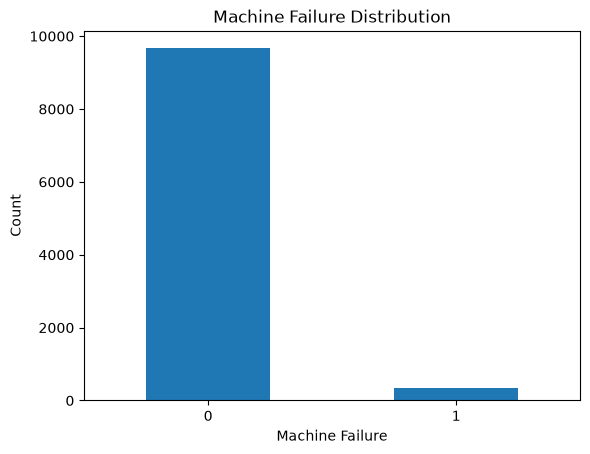

In [19]:
failure_counts.plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.savefig("../figures/eda/machine_failure_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [18]:
import os
os.makedirs("..//figures/eda",exist_ok=True)

In [20]:
import os
import matplotlib.pyplot as plt

os.makedirs("../figures/eda", exist_ok=True)

def save_fig(filename, folder="../figures/eda"):
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/{filename}", dpi=300, bbox_inches="tight")

### Class Distribution

The target variable is highly imbalanced.

Among 10,000 observations:
- 9,661 observations correspond to normal operation (`Machine failure = 0`)
- 339 observations correspond to machine failure (`Machine failure = 1`)
- The overall failure rate is 3.39%

This strong class imbalance indicates that accuracy alone may provide a misleading evaluation of predictive performance. Therefore, later machine learning experiments will place greater emphasis on metrics such as Precision, Recall, F1-score, and PR-AUC.

From a maintenance perspective, false negatives are particularly important because they represent actual machine failures that are incorrectly classified as normal operation.

In [21]:
process_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[process_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


### Descriptive Statistics of Process Variables

The process variables show different levels of variability across operating conditions.

- Air and process temperatures are relatively concentrated around their mean values.
- Rotational speed shows a wider operating range, with values extending up to 2,886 rpm.
- Torque also varies substantially, ranging from 3.8 to 76.6 Nm.
- Tool wear spans from 0 to 253 minutes, representing different stages of tool usage.

At this stage, extreme observations are not removed because they may contain meaningful information related to machine failures. Their relationship with failure events will be examined in subsequent analyses.

In [22]:
failure_comparison = (
    df.groupby("Machine failure")[process_features]
      .mean()
      .T
)

failure_comparison.columns = ["Normal", "Failure"]

failure_comparison

,Normal,Failure
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


### Comparison of Normal and Failure Conditions

The average operating conditions show noticeable differences between normal and failure observations.

- Machine failures are associated with higher average torque.
- Tool wear is also substantially higher in the failure group.
- Rotational speed is slightly lower on average for failure observations.
- Air and process temperatures show relatively small differences between the two groups.

These results suggest that torque and tool wear may be important variables for failure-related analysis. However, mean differences alone do not establish causality or statistical significance, so their distributions will be examined in more detail.

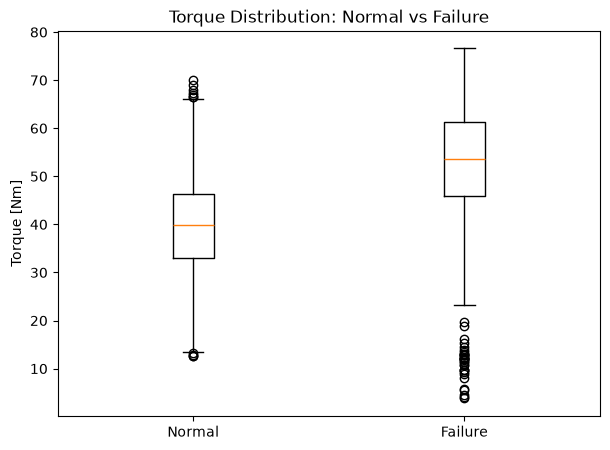

In [23]:
normal_torque = df[df["Machine failure"] == 0]["Torque [Nm]"]
failure_torque = df[df["Machine failure"] == 1]["Torque [Nm]"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal_torque, failure_torque],
    tick_labels=["Normal", "Failure"]
)

plt.title("Torque Distribution: Normal vs Failure")
plt.ylabel("Torque [Nm]")

save_fig("torque_normal_vs_failure.png")
plt.show()

### Torque Distribution by Machine Condition

The failure group shows a noticeably higher torque distribution than the normal group, with both the median and interquartile range shifted toward higher torque values.

However, several failure observations also occur at unusually low torque levels. This suggests that machine failure is not simply associated with high torque alone and may depend on interactions between torque and other operating variables such as rotational speed.

Therefore, torque will be retained as an important candidate variable for subsequent failure analysis and predictive modeling.

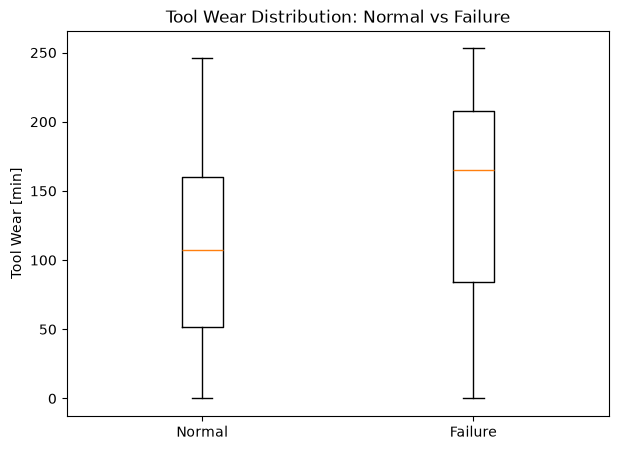

In [24]:
normal_tool_wear = df[df["Machine failure"] == 0]["Tool wear [min]"]
failure_tool_wear = df[df["Machine failure"] == 1]["Tool wear [min]"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal_tool_wear, failure_tool_wear],
    tick_labels=["Normal", "Failure"]
)

plt.title("Tool Wear Distribution: Normal vs Failure")
plt.ylabel("Tool Wear [min]")

save_fig("tool_wear_normal_vs_failure.png")
plt.show()

### Tool Wear Distribution by Machine Condition

The failure group shows a substantially higher tool wear distribution than the normal group.

The median tool wear is higher for failure observations, and the interquartile range is also shifted toward greater levels of accumulated tool usage.

However, considerable overlap exists between the two groups. This indicates that high tool wear alone is not sufficient to determine machine failure, although it may represent an important risk factor when combined with other operating conditions.

Therefore, tool wear will be retained as an important feature for subsequent failure prediction and process-risk analysis.

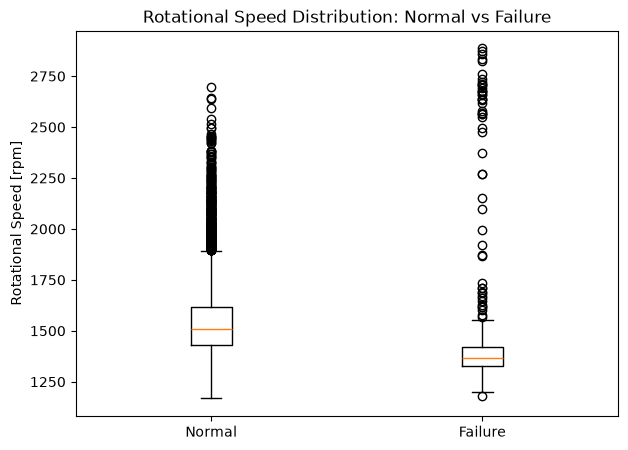

In [25]:
normal_speed = df[df["Machine failure"] == 0]["Rotational speed [rpm]"]
failure_speed = df[df["Machine failure"] == 1]["Rotational speed [rpm]"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal_speed, failure_speed],
    tick_labels=["Normal", "Failure"]
)

plt.title("Rotational Speed Distribution: Normal vs Failure")
plt.ylabel("Rotational Speed [rpm]")

save_fig("rotational_speed_normal_vs_failure.png")
plt.show()

### Rotational Speed Distribution by Machine Condition

The failure group generally shows a lower rotational speed distribution than the normal group.

Most failure observations are concentrated at relatively lower rotational speeds, while a smaller number of failures also occur at unusually high rotational speeds.

This pattern suggests that rotational speed alone is unlikely to explain machine failure. Its interaction with other operating variables, particularly torque, may provide more meaningful information about failure-related operating conditions.

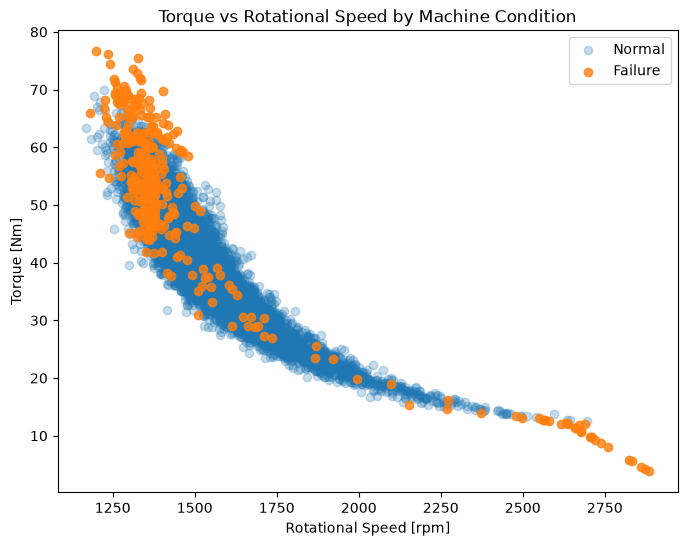

In [26]:
normal_data = df[df["Machine failure"] == 0]
failure_data = df[df["Machine failure"] == 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    normal_data["Rotational speed [rpm]"],
    normal_data["Torque [Nm]"],
    alpha=0.25,
    label="Normal"
)

plt.scatter(
    failure_data["Rotational speed [rpm]"],
    failure_data["Torque [Nm]"],
    alpha=0.8,
    label="Failure"
)

plt.title("Torque vs Rotational Speed by Machine Condition")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend()

save_fig("torque_vs_rotational_speed.png")
plt.show()

### Torque and Rotational Speed Relationship

The scatter plot shows a strong inverse relationship between rotational speed and torque across the dataset.

Failure observations are more frequently concentrated in the low-speed, high-torque region, suggesting that this operating condition may be associated with elevated failure risk.

However, failures are not limited to a single narrow region. Some failure observations also appear in other parts of the operating space, indicating that machine failure is likely influenced by multiple interacting factors rather than a single variable alone.

This result suggests that the interaction between torque and rotational speed is important for understanding machine condition and should be considered in subsequent predictive modeling and risk analysis.

In [27]:
type_failure_rate = df.groupby("Type")["Machine failure"].mean() * 100
type_failure_rate

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64

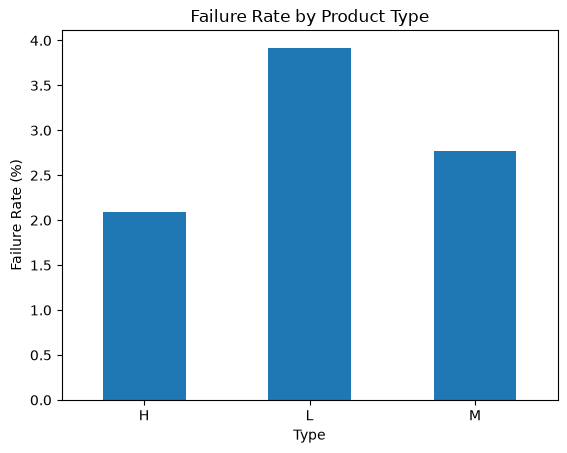

In [28]:
type_failure_rate.plot(kind="bar")

plt.title("Failure Rate by Product Type")
plt.xlabel("Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)

save_fig("failure_rate_by_type.png")
plt.show()

### Failure Rate by Product Type

The observed machine failure rate differs across product types.

- Type L shows the highest failure rate.
- Type M shows an intermediate failure rate.
- Type H shows the lowest failure rate.

Because these values represent failure rates within each product type rather than raw failure counts, the result suggests that product type may contain useful information related to failure risk.

However, this descriptive comparison does not establish that product type directly causes machine failure. Differences in sample size and operating conditions should also be considered before drawing stronger conclusions.

In [29]:
type_summary = (
    df.groupby("Type")["Machine failure"]
      .agg(
          Total_Observations="count",
          Failures="sum",
          Failure_Rate="mean"
      )
)

type_summary["Failure_Rate (%)"] = type_summary["Failure_Rate"] * 100

type_summary

,Total_Observations,Failures,Failure_Rate,Failure_Rate (%)
Type,,,,
H,1003,21,0.020937,2.093719
L,6000,235,0.039167,3.916667
M,2997,83,0.027694,2.769436


### Product Type Summary

The dataset contains different numbers of observations across product types.

- Type H: 1,003 observations, 21 failures, failure rate of 2.09%
- Type L: 6,000 observations, 235 failures, failure rate of 3.92%
- Type M: 2,997 observations, 83 failures, failure rate of 2.77%

Type L exhibits the highest observed failure rate, while Type H shows the lowest.

Importantly, the comparison is based on within-type failure rates rather than raw failure counts, since the sample sizes of the three product types differ substantially.

These descriptive results suggest that product type may contain useful information for failure prediction, although further analysis is required before interpreting the relationship as causal.

In [30]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_mode_counts = (
    df[failure_modes]
    .sum()
    .sort_values(ascending=False)
)

failure_mode_counts

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

In [31]:
failure_mode_per_observation = df[failure_modes].sum(axis=1)

failure_mode_per_observation.value_counts().sort_index()

0    9652
1     324
2      23
3       1
Name: count, dtype: int64

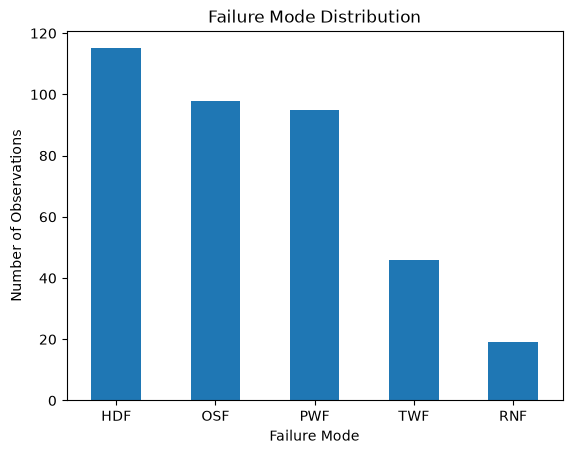

In [32]:
failure_mode_counts.plot(kind="bar")

plt.title("Failure Mode Distribution")
plt.xlabel("Failure Mode")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

save_fig("failure_mode_distribution.png")
plt.show()

### Failure Mode Distribution

The failure-mode indicators show that heat dissipation failure (HDF) is the most frequently recorded failure mode, followed by overstrain failure (OSF) and power failure (PWF).

Failure modes are not mutually exclusive. Among the 10,000 observations:

- 9,652 observations contain no recorded failure mode.
- 324 observations contain one failure mode.
- 23 observations contain two simultaneous failure modes.
- 1 observation contains three simultaneous failure modes.

Therefore, the sum of failure-mode counts should not be interpreted as the number of unique failed observations, because multiple failure mechanisms may coexist within a single observation.

The failure-mode variables will be used for descriptive analysis and data-quality validation, but they will not be included as predictors of `Machine failure` to avoid target leakage.

In [33]:
any_failure_mode = (df[failure_modes].sum(axis=1) > 0).astype(int)

failure_consistency = pd.crosstab(
    df["Machine failure"],
    any_failure_mode,
    rownames=["Machine failure"],
    colnames=["Any failure mode"]
)

failure_consistency

Any failure mode,0,1
Machine failure,,
0,9643,18
1,9,330


### Failure Label Consistency Check

A consistency check was performed between the overall `Machine failure` target and the five failure-mode indicators.

Most observations were consistent, but 27 observations showed disagreement:

- 18 observations had at least one recorded failure mode while `Machine failure = 0`.
- 9 observations had `Machine failure = 1` while none of the five failure modes were recorded.

These observations are retained rather than manually corrected, because the original target labels should not be altered without additional ground-truth information.

For subsequent machine-learning experiments, `Machine failure` will be treated as the primary target, while the individual failure-mode variables will be excluded from the predictor set to avoid target leakage.

A sensitivity analysis excluding inconsistent observations may be conducted later to assess their impact on model performance.

In [34]:
mismatch_mask = df["Machine failure"] != any_failure_mode

mismatch_df = df.loc[
    mismatch_mask,
    ["UDI", "Product ID", "Type", "Machine failure"] + failure_modes
]

print("Number of inconsistent observations:", len(mismatch_df))

mismatch_df.head(10)

Number of inconsistent observations: 27


,UDI,Product ID,Type,Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,0,0,0,0,0,1
1302,1303,L48482,L,0,0,0,0,0,1
1437,1438,H30851,H,1,0,0,0,0,0
1748,1749,H31162,H,0,0,0,0,0,1
2072,2073,L49252,L,0,0,0,0,0,1
2559,2560,L49739,L,0,0,0,0,0,1
2749,2750,M17609,M,1,0,0,0,0,0
3065,3066,M17925,M,0,0,0,0,0,1
3452,3453,H32866,H,0,0,0,0,0,1
4044,4045,M18904,M,1,0,0,0,0,0


In [35]:
mode_mismatch_counts = (
    mismatch_df[mismatch_df["Machine failure"] == 0][failure_modes]
    .sum()
    .sort_values(ascending=False)
)

mode_mismatch_counts

RNF    18
TWF     0
HDF     0
PWF     0
OSF     0
dtype: int64

Notably, all 18 observations with a recorded failure mode but no overall machine-failure label were associated exclusively with the RNF (Random Failure) indicator, suggesting that RNF behaves differently from the four condition-related failure modes.

In [36]:
df.loc[
    df["RNF"] == 1,
    ["UDI", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
]

,UDI,Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,0,0,0,0,0,1
1302,1303,0,0,0,0,0,1
1748,1749,0,0,0,0,0,1
2072,2073,0,0,0,0,0,1
2559,2560,0,0,0,0,0,1
3065,3066,0,0,0,0,0,1
3452,3453,0,0,0,0,0,1
3611,3612,1,1,0,0,0,1
5471,5472,0,0,0,0,0,1
5489,5490,0,0,0,0,0,1


In [37]:
df.loc[
    (df["RNF"] == 1) & (df["Machine failure"] == 1),
    ["UDI", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
]

,UDI,Machine failure,TWF,HDF,PWF,OSF,RNF
3611,3612,1,1,0,0,0,1


### Failure Label Consistency Audit

A consistency audit was conducted between the overall `Machine failure` target and the five failure-mode indicators (`TWF`, `HDF`, `PWF`, `OSF`, and `RNF`).

A total of 27 inconsistent observations were identified:

- 18 observations had `RNF = 1` while `Machine failure = 0`.
- 9 observations had `Machine failure = 1` while all five recorded failure modes were equal to zero.
- Among the 19 observations with `RNF = 1`, only one was also labeled as `Machine failure = 1`.

The inconsistent observations are retained in the original dataset because there is insufficient ground-truth information to justify manually modifying the labels.

For predictive modeling, `Machine failure` will be used as the primary target variable, while the individual failure-mode indicators will be excluded from the predictor set to avoid target leakage.

The impact of these 27 inconsistent observations will later be evaluated through a sensitivity analysis.

## Feature Engineering

To incorporate domain-relevant information beyond the original sensor variables, two physically interpretable features are constructed.

1. **Temperature Difference**: the difference between process and ambient air temperature.
2. **Mechanical Power**: an approximation of rotational mechanical power derived from torque and rotational speed.

These features are generated without using the target variable and therefore do not introduce target leakage.

In [38]:
df["Temperature difference [K]"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

df["Mechanical power [kW]"] = (
    df["Torque [Nm]"]
    * 2
    * np.pi
    * df["Rotational speed [rpm]"]
    / 60
    / 1000
)

In [39]:
engineered_features = [
    "Temperature difference [K]",
    "Mechanical power [kW]"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature difference [K],10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
Mechanical power [kW],10000.0,6.279745,1.067418,1.148441,5.561184,6.271027,7.003003,10.469923


In [40]:
df.groupby("Machine failure")[engineered_features].mean().T

Machine failure,0,1
Temperature difference [K],10.021571,9.403835
Mechanical power [kW],6.244548,7.282819


### Engineered Feature Comparison

Two physically interpretable features were derived from the original process variables: temperature difference and mechanical power.

Failure observations show a lower average temperature difference than normal observations, while average mechanical power is noticeably higher in the failure group.

The higher mechanical power in failure observations is consistent with the previously observed differences in torque and rotational speed. However, mean differences alone are insufficient to characterize the full failure pattern, so the distributions of these engineered features will be examined next.

These features will later be evaluated to determine whether they provide additional predictive information beyond the original sensor variables.

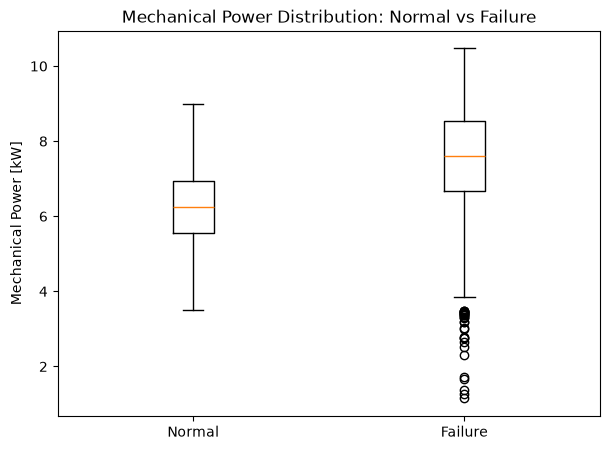

In [41]:
normal_power = df[df["Machine failure"] == 0]["Mechanical power [kW]"]
failure_power = df[df["Machine failure"] == 1]["Mechanical power [kW]"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal_power, failure_power],
    tick_labels=["Normal", "Failure"]
)

plt.title("Mechanical Power Distribution: Normal vs Failure")
plt.ylabel("Mechanical Power [kW]")

save_fig("mechanical_power_normal_vs_failure.png")
plt.show()

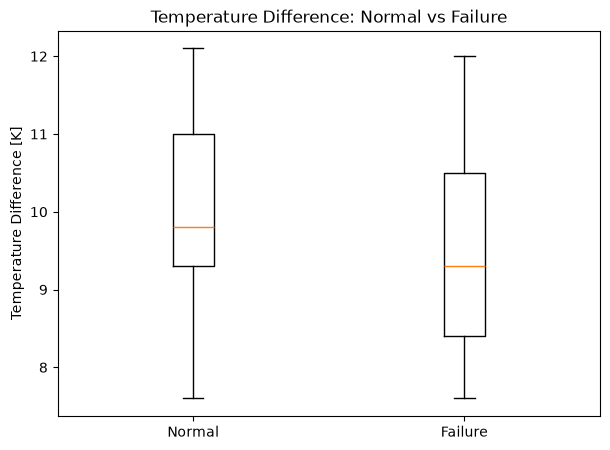

In [42]:
normal_temp_diff = df[df["Machine failure"] == 0]["Temperature difference [K]"]
failure_temp_diff = df[df["Machine failure"] == 1]["Temperature difference [K]"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal_temp_diff, failure_temp_diff],
    tick_labels=["Normal", "Failure"]
)

plt.title("Temperature Difference: Normal vs Failure")
plt.ylabel("Temperature Difference [K]")

save_fig("temperature_difference_normal_vs_failure.png")
plt.show()

### Engineered Feature Distributions

The engineered features show distinct patterns between normal and failure observations.

Mechanical power is generally higher in the failure group, with a clear upward shift in the median and interquartile range. However, several failure observations also occur at unusually low power levels. These observations are retained because they may represent meaningful failure-related operating regimes rather than data errors.

Temperature difference is generally lower for failure observations than for normal observations. This suggests that the thermal relationship between the process and ambient environment may contain additional information beyond the two temperature measurements considered separately.

Overall, the engineered features provide interpretable summaries of interacting operating conditions, but neither feature alone completely separates normal and failure observations.

In [43]:
correlation_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Temperature difference [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Mechanical power [kW]",
    "Tool wear [min]"
]

correlation_matrix = df[correlation_features].corr()

correlation_matrix.round(2)

,Air temperature [K],Process temperature [K],Temperature difference [K],Rotational speed [rpm],Torque [Nm],Mechanical power [kW],Tool wear [min]
Air temperature [K],1.00,0.88,-0.70,0.02,-0.01,-0.01,0.01
Process temperature [K],0.88,1.00,-0.27,0.02,-0.01,-0.01,0.01
Temperature difference [K],-0.70,-0.27,1.00,-0.02,0.01,0.01,-0.01
Rotational speed [rpm],0.02,0.02,-0.02,1.00,-0.88,-0.81,0.00
Torque [Nm],-0.01,-0.01,0.01,-0.88,1.00,0.98,-0.00
Mechanical power [kW],-0.01,-0.01,0.01,-0.81,0.98,1.00,-0.00
Tool wear [min],0.01,0.01,-0.01,0.00,-0.00,-0.00,1.00


### Correlation Analysis

The correlation analysis reveals several strong relationships among the process variables.

- Rotational speed and torque exhibit a strong negative correlation (`r ≈ -0.88`).
- Mechanical power is highly positively correlated with torque (`r ≈ 0.98`) and negatively correlated with rotational speed (`r ≈ -0.81`).
- Air and process temperatures are strongly positively correlated (`r ≈ 0.88`).
- Tool wear shows little linear correlation with the other operating variables.

The strong correlations involving mechanical power are expected because the feature was mathematically derived from torque and rotational speed.

These relationships suggest potential multicollinearity when using the original and engineered variables simultaneously in linear models. Therefore, feature sets will later be compared separately rather than assuming that adding all engineered features necessarily improves predictive performance.

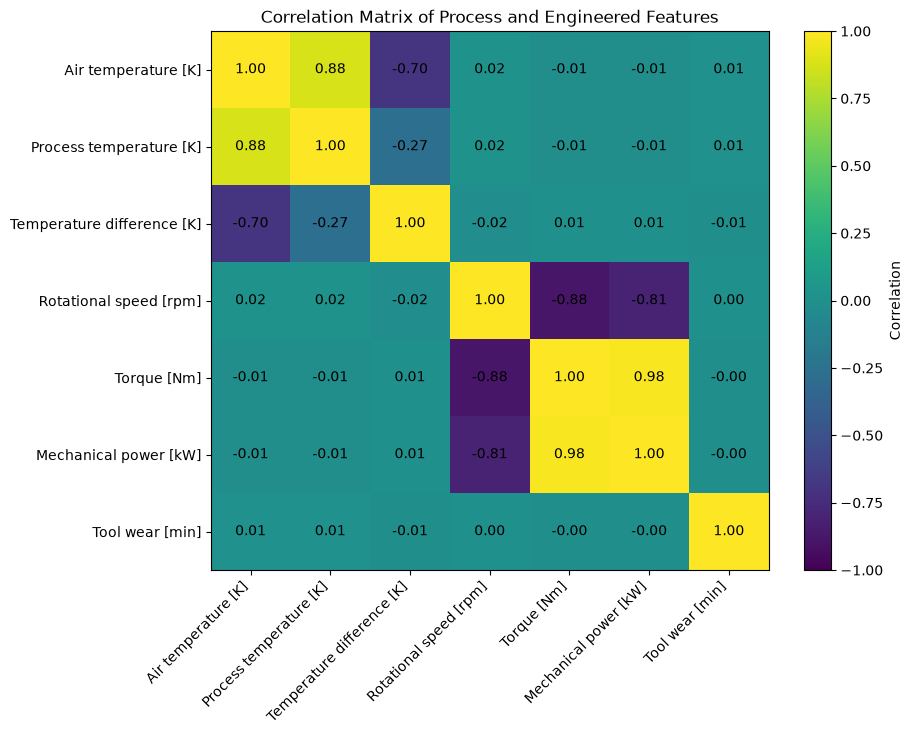

In [44]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

for i in range(len(correlation_features)):
    for j in range(len(correlation_features)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Process and Engineered Features")

save_fig("correlation_matrix.png")
plt.show()

In [45]:
os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/ai4i2020_features.csv",
    index=False
)

print("Processed dataset saved.")

Processed dataset saved.
